# Using supervised learning and unsupervised learning algorithms to analyze and detect fake news
#### By Ruijie Zheng, and Chandan Murthy, Fall 2019

<img src="fake news.jpg" width="400" height="300"> 

## Introduction

Fake

### Data source used in this project

In this project, we will use the "Liar" dataset, which is a benchmark dataset for fake news detection proposed by William Yang Wang in 2017. Feel free to check out the original paper [here](https://arxiv.org/pdf/1705.00648.pdf). This dataset contains 12.8K manually labeled statements in various contexts from [PolitiFact.com](https://www.politifact.com/), a fact-checking wesite provides detailed analysis report and links to source documents for each case. Compared to many previous fake news datasets, the "Liar" dataset is an order of magnitude larger, which could allow us to train the complicated neural network models much better. 
In the "liar" dataset, it labels each statement into six categories: barely true, half true, mostly true, true, false, and pants-on-fire. Below are three examples of statement labeled as false and pants-on-fire from the original paper.

<img src="example.PNG" width="800" height="500"> 

#### Misinformation vs. Disinformation

In our dataset, misinformation is labled as false, and disinformation is labeled as pants on fire. Notice the difference between these two concepts. Misinformation refers the information that may not be accurate or complete,  whereas disinformation additionally assumes malicious motives to mislead the people. So we consider disinformation as a subset of misinformation. In some cases, the distinctions between these two are not so clear, which makes the fake-news detection task much more challenging. 

In addition to the original statements, this dataset also incorporate various metadata about the speakers and the statements themselves, including the topics, context of the statements, speakers' jobs, the speakers' credit history count (Number of true, false, pant-on-fire statement that he(she) made in the history), and speakers' party affiliations. In this project, we will specifically incorporate speaker's credit history into our model because we think that it might be the most indicative among all the metadata provided in this dataset. 

## Outline

1.Getting Started with the liar dataset
  - 1.1 Required Libraries
  - 1.2 Getting start on the dataset
  - 1.3 Exploring the dataset
  - 1.4 Data cleaning
  - 1.5 Text preprocessing
  
2.Exploring the structure of the dataset with unsupervised learning algorithms 
  - 2.1 Visualizing the text: exploratory data analysis <br>
  - 2.2 Doc2vec embedding and visualizaton through dimensional reduction     <br>
  - 2.3 Topic modelling <br>
  
3.Fake news detection with supervised learning algorithms
  - 3.1 Data preparation
  - 3.2 Basedline model: K Nearest Neighbors
  - 3.3 Support Vector Machine
  - 3.4 Random Forest
  - 3.5 Deep learning - Feed-forward Neural Network <br>
  - 3.6 Comparing perfomance of different machine learning models on test set & hypothesis testing<br>
  
4.Conclusions
****

### 1.1 Required libraries

1. **Scipy**: offering lots of functionality in scientific computing optimization, linear algebra, integration, FFT, etc. In this tutorial, we will only use the stats.ttest_rel function for paired t-test.
2. **Numpy**: providing fast implementation for a large collection of high-level mathematical functions to work on matrices
3. **Pandas**: offering data structures and operations for manipulating the tables. 
4. **Matplotlib & Seaborn**: visualization tools. We will make barplot and scatter plot by Seaborn library in this tutorial.
5. **nltk & gensim**: providing a lot of useful natural language processing (NLP) toolkits to process the text data, including but not limited to tokenization, lemmatization, tf-idf models, Doc2Vec models.
6. **wordcloud**: generate the word cloud from the text based on some given weights(e.g. tf-idf score)
7. **scikit-learn**:  machine learning library that features various classification and also unsupervised learning algorithms that we will use in this tutorial.
8. **tensorflow**: a popular library for implementing deep-learning algorithms
9. **keras**:  a high-level neural networks API that could runs on top of tensorflow that allows for easy and fast prototyping

!pip install wordcloud
!pip install nltk
import nltk
nltk.download("all")
!pip install gensim
!pip install keras
!pip install tensorflow

In [1]:
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image
from IPython.core.display import HTML 
from pprint import pprint
from more_itertools import take
import operator
import re
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
%matplotlib inline
import seaborn as sns
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
import gensim
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, Phrases, LdaModel
from gensim.test.utils import common_texts
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.test.utils import get_tmpfile
from sklearn import svm
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize, StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.kernel_approximation import Nystroem
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras import regularizers
from keras.metrics import categorical_accuracy
import tensorflow as tf

Using TensorFlow backend.


### 1.2 Getting started on the dataset

First we read in the training, cross-validation and test data

In [2]:
columns = ["ID", "label","statement","subject","speaker","speaker's job title",\
           "state info","party affliation","barely true counts","false counts",\
           "half true counts","mostly true counts", "pants on fire counts", "the context"]
# Read the training, cross-validation, and testing data
train_df = pd.read_table("train.tsv",names = columns)
valid_df = pd.read_table("valid.tsv",names = columns)
test_df  = pd.read_table("test.tsv", names = columns)

In [3]:
train_df.head()

,ID,label,statement,subject,speaker,speaker's job title,state info,party affliation,barely true counts,false counts,half true counts,mostly true counts,pants on fire counts,the context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


### 1.3 Exploring the dataset

First, we take a look at how many training examples we have for each class labels, since whether the dataset is balanced a lot would change our choice of machine learning models to use.

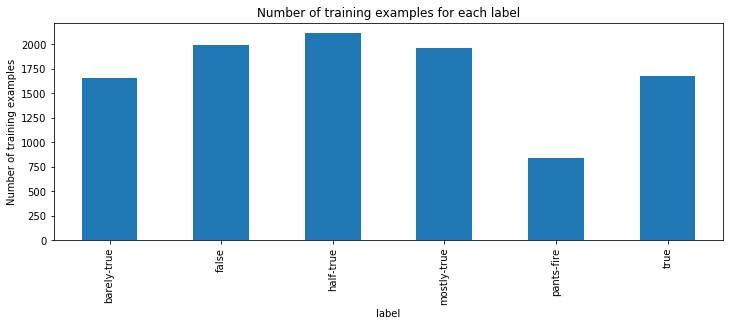

In [4]:
ax = train_df.groupby(["label"])["statement"].count().plot.bar\
    (title="Number of training examples for each label", figsize=(12,4))
_ = ax.set_xlabel("label")
_ = ax.set_ylabel("Number of training examples")

So as we see, it's roughly a balanced dataset. Only the number of training examples with pants-fire is much less than other categories.

Next, we take a look at the topics of the statements in this dataset. We count the number of occurrences for each topic, and sort the topics based on their occurrences in this dataset.

In [5]:
topics = {}
# Counting the number of occurrences for each topic
for _, row in train_df.iterrows():
    try:
        subjects = row["subject"].split(",")
        for sub in subjects:
            if sub in topics:
                topics[sub]+=1
            else:
                topics[sub]=1
    except:
        # Some rows are missing the subject entry
        pass

# Sorting the topics based on its frequency
sorted_list = sorted(topics.items(), key=operator.itemgetter(1), reverse = True)
print("top 10 topics:\n{}".format(sorted_list[:10]))

top 10 topics:
[('economy', 1162), ('health-care', 1128), ('taxes', 994), ('federal-budget', 744), ('education', 728), ('jobs', 711), ('state-budget', 696), ('candidates-biography', 653), ('elections', 607), ('immigration', 532)]



Then we make a barplot of the top 10 topics in the dataset and the number of their occurences.

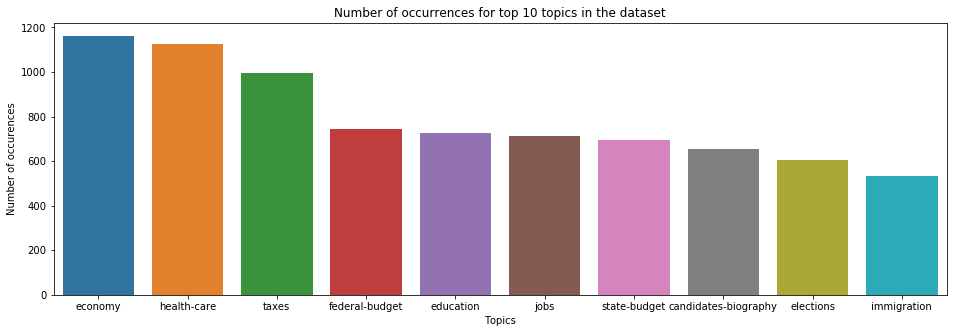

In [6]:
top10_list = sorted_list[:10]
top10_topics = [x[0] for x in top10_list] # List of top-10 topics in the dataset
top10_frequency = [x[1] for x in top10_list] # Frequency of top-10 topics

# Make a barplot of the top 10 topics and the number of their occurrences
figure_size = (16,5)
fig, ax = plt.subplots(figsize=figure_size)
ax = sns.barplot(x = top10_topics, y = top10_frequency)
_  = ax.set(xlabel="Topics", ylabel= "Number of occurences")
_  = ax.set_title("Number of occurrences for top 10 topics in the dataset")

### 1.4 Data cleaning

First, let's take a look at the text data in this dataset that we will mainly work with. We compute the length of each statement and put them into 10 fixed-size buckets. Each bucket has length 10 (0-9, 10-19, ... ). Then we make a barplot of the length of statements in this dataset.

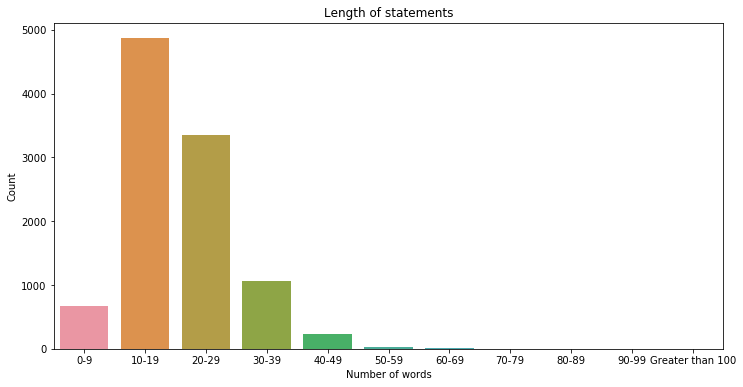

In [7]:
length = {0:0, 1:0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0 , 10:0}
index = []
i = 0
for _,row in train_df.iterrows():
    tokens = word_tokenize(row["statement"].lower())
    if (int(len(tokens)/10) < 10):
        length[int(len(tokens)/10)] += 1
    else:
        length[10]+=1
        index.append(i)
    i+=1

# Getting the number of counts for each bucket
y = [i[1] for i in length.items()]

# In order for the readibility of our plot, we will do a mapping 
# here to explicitly show the range of the length for each of the bucket.
mapping = {0:"0-9", 1:"10-19", 2:"20-29", 3:"30-39", 4:"40-49", 5:"50-59",\
           6:"60-69", 7:"70-79", 8:"80-89", 9:"90-99", 10:"Greater than 100"}
x = list(length.keys())
x = [mapping[i] for i in x]

# Making a barplot
fig_size = (12, 6)
fig, ax = plt.subplots(figsize=fig_size)
ax = sns.barplot(x = x, y = y)
_  = ax.set(xlabel="Number of words", ylabel= "Count")
_  = ax.set_title("Length of statements")

As we see from the graph, most of the statements in this dataset are very short. The majority of the statements have length less than 30. Only a few of the statements contained in the dataset have length greater than 50.

Let's take a look at the outliers that have length greater than 100, which we have already computed.

In [8]:
# The index of the rows which have length of the statement greater than 100
index

[1280, 2142, 6119, 7550]

In [9]:
train_df.iloc[1280]["statement"]

'Hospitals, doctors, MRIs, surgeries and so forth are more extensively used and far more expensive in this country than they are in many other countries.\'\'\thealth-care\tmitt-romney\tFormer governor\tMassachusetts\trepublican\t34\t32\t58\t33\t19\ta Fox News Sunday interview\r\n9874.json\tbarely-true\tObamacare cuts seniors Medicare.\thealth-care,medicare\ted-gillespie\tRepublican strategist\tWashington, D.C.\trepublican\t2\t3\t2\t2\t1\ta campaign email.\r\n3072.json\tmostly-true\tThe refusal of many federal employees to fly coach costs taxpayers $146 million annually.\tgovernment-efficiency,transparency\tnewsmax\tMagazine and website\tFlorida\tnone\t0\t0\t0\t1\t0\tan e-mail solicitation\r\n2436.json\tmostly-true\tFlorida spends more than $300 million a year just on children repeating pre-K through 3rd grade.\teducation\talex-sink\t\tFlorida\tdemocrat\t1\t2\t2\t4\t0\tfigures cites on campaign website\r\n9721.json\ttrue\tMilwaukee County Sheriff David A. Clarke Jr. advised citizens to 

So as we see, this statement has not been cleaned for some reason. It has a lot of nonsense characters which is probably because of the scraping process. Since we only have 4 of these, we will just delete those outliers.

In [10]:
# Drop those rows in the orignal table
train_df = train_df.drop(index)

Next, since we will take into account the credit history (columns from barely true count to pants on fire counts) of the speaker for our models, we fill in zeros for any row which have are missing those counts in the history.

In [11]:
train_df["barely true counts"].fillna(value = 0, inplace = True)
train_df["false counts"].fillna(value = 0, inplace = True)
train_df["half true counts"].fillna(value = 0, inplace = True)
train_df["mostly true counts"].fillna(value = 0, inplace = True)
train_df["pants on fire counts"].fillna(value = 0, inplace = True)

### 1.5 Text preprocessing

In order to train unsupervised learning and supervised learning models on our dataset, we will need to do some transformations on our text data first. First, we need to consruct a corpus of our text data, which is a list of all the statements in the dataset. For example, a simple corpus could be [ ["I","am", "back"], ["How", "are, "you] ]. So to construct the corpus, we will first tokenize each statement into a list of words. Then we will remove the punctuation and stop words (commonly appearing words like the or is, which are meaningless in our machine learning models) from our texts. <br>
In addition to the whole corpus of the training set, here we will also construct the corpus that only consist of training examples labeled as true or only trainig examples labeled as pants-fire in order to generate the word clouds for these two seperate labels later.

In [12]:
true_df = train_df[train_df.label == "true"]
fake_df = train_df[train_df.label == "pants-fire"]

In [13]:
# Create a corpus based on the dataframe given (could be training set or 
# cross-validation set or test set)
def create_corpus(df):
    corpus = [] # A corpus of all the statements
    true_corpus = [] # A corpus of all the true statements
    fake_corpus = [] # A corpus of all the statements labeled as pants-on-fire

    reg1 = r"[0-9]" # Match and remove all the numbers
    reg2 = r"[^\w]" # Match and remove all non-alphanumeric character
    stop_words = set(stopwords.words('english')) # Remove the stop words
    # Since said appear a lot of times in our dataset, and we think they
    # don't add much information to the sentence, so we add them to the 
    # stopwords set
    stop_words.add("says")
    stop_words.add("said")
    
    for _, row in df.iterrows():
        # First, we tokenize the document
        tokens = word_tokenize(row["statement"].lower()) 
        # Remove all the punctuation) and all the numbers in the text,
        # and also all the stop_words
        tokens = [w for w in tokens if not w in stop_words \
                  and len(re.findall(reg1, w))==0 and len(re.findall(reg2, w))==0]
        # Finally, we lemmatize the document. We prefer lemmatizer here over a stemmer
        # because it could produce a more readable words, which could be better for 
        # topic modelling that we will do later
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
        
        corpus.append(tokens)
        if (row["label"] == "pants-fire"):
            fake_corpus.append(tokens)
        elif (row["label"] == "true"):
            true_corpus.append(tokens)
    return corpus, true_corpus, fake_corpus

# Generate the corpus for training set, cross-validation set, test set as well
# as set of fake news and true news from the training set
train_corpus, true_corpus, fake_corpus = create_corpus(train_df)
valid_corpus, _, _ = create_corpus(valid_df)
test_corpus, _,  _ = create_corpus(test_df)
#Show the outout of the first sentence after preprocessing
train_corpus[0]

['annies', 'list', 'political', 'group', 'support', 'abortion', 'demand']

Then we add bigrams to our training corpus. In natural language processing, bigrams refers to representing two adjacent words as one token such "machine learning". Without bigrams, we could only represent "machine learning" as "machine" and "learning", which may cause the lost of information in this case. 

In [14]:
# Add bigrams to trainig corpus (only ones that appear 20 times or more).
# The larger the min_count, the harder to form a bigram
bigram_model = Phrases(train_corpus, min_count=20)
trigram_model = Phrases(bigram_model[train_corpus], min_count=20)  
for i in range(len(train_corpus)):
    for token in bigram_model[train_corpus[i]]:
        if '_' in token:
            # Token is a bigram, so we add to the training corpus.
            train_corpus[i].append(token)
# Display the results after computing the bigram
print(train_corpus[5])

['chicago', 'bear', 'starting', 'quarterback', 'last', 'year', 'total', 'number', 'tenured', 'uw', 'faculty', 'fired', 'last', 'two', 'decade', 'last_year']


We do want to point out out that there are limitations with the text processing that we do here. We might lose useful information of some statements for deleting all the numbers. For example, we could have a fake news which is like "Scientists estimate that by 2050, the gloal average temperature will increase by 2 Fahrenheit". It is a fake news since the actual prediction of global mean temperature growth is much higher than 2 Fahrenheit. In this case, by deleting 2, we cannot distinguish the fake news from the true news. However, our models that we will train in this tutorial will not do the explicit fact-checking and will focus on the linguistic features of the statement, so it's safe to delete those numbers. However, to get a better performance of the automated fake news detection, we might want to do the extra fact-checking and keep those numbers in the preprocessing stage.

# Explore the dataset with unsupervised learning techniques

### 2.1 Visualizing the text: exploratory data analysis

To visualize and compare the true news and fake news, we will train the tf-idf on the whole corpus, as well as the set of true label and pants-fire label statements. Then we generate the word cloud based on the tf-idf score to see the difference etween true news and fake news.

In [15]:
# Build the dictionary for the entire corpus, including the cross-validation and test corpus.
# However, we will not train on cross-validation and test corpus.  
dictionary = Dictionary(train_corpus + valid_corpus + test_corpus) 

# Training the tfidf model on given corpus
def tfidf_model(corpus):
    # Set-up the tf-idf on the training corpus first
    bow = [dictionary.doc2bow(text) for text in corpus] # Bag-of-word representation
    tfidf = TfidfModel(bow) # Set-up the tf-idf model
    return tfidf

tfidf = tfidf_model(train_corpus)
true_news_tfidf  = tfidf_model(true_corpus)
fake_news_tfidf  = tfidf_model(fake_corpus)

Here, get_weights function will take bag-of-word representation of the corpus as the input, and output the weights of all the words appeared in the corpus as a dictionary. For example, a simple weight output could be: {"like":0.4, "life":0.2,"there":0.1}

In [16]:
# Notice here, the set_of_statements is an extra parameter for the function to determine
# which tf-idf model to extract the weight from. To generate the weights of each word
# for the whole training corpus, set_of_statements = "whole". To generate the weights for
# set of fake news, set_of_statements = "fake_news". Other_wise, it will generate the weights
# fot the set of true_news
def get_weights(bow, set_of_statements="whole"):
    # Store the weights of all the words in ture-labeled training set based on tf-idf model
    weights = {}
    statement = []
    # Fetching the weights from tf-idf model
    for i in range(len(bow)):
        if (set_of_statements == "whole"):
            statement = tfidf[bow[i]]
        elif (set_of_statements == "fake_news"):
            statement = fake_news_tfidf[bow[i]]
        else:
            statement = true_news_tfidf[bow[i]]
        for j in range(len(statement)):
            if dictionary[statement[j][0]] not in weights:
                weights[dictionary[statement[j][0]]] = statement[j][1]
    return weights

In [17]:
# Show the tf-idf weights computed on the training set
bow = [dictionary.doc2bow(text) for text in train_corpus] 
weights = get_weights(bow)
# Here since the vocabulary is too big, we will only print five of them
print(take(5, weights.items()))

[('abortion', 0.2727943735333422), ('annies', 0.5748748239270743), ('demand', 0.415184752968372), ('group', 0.32101318651896243), ('list', 0.3824309508045022)]


Then we write a function to generate the word cloud for each set of statements.

In [18]:
# Same as above, the set_of_statements is an extra parameter for the function to determine
# which set of statements to work with. If set_of_statements="whole", it will generate
# the word clouds for the whole corpus. If set_of_statements="fake_news", it will generate 
# the word clouds for the corpus of fake news. Otherwise, it will generate the word clouds for
# the corpus of true news.
def generate_word_cloud(bow, image_name, set_of_statements="whole"):
    # Get the weights of each word word from the bag-of-word representation
    if (set_of_statements == "whole"):
        weights  = get_weights(bow) 
    elif (set_of_statements == "fake_news"):
        weights  = get_weights(bow, "fake_news") 
    else:
        weights  = get_weights(bow, "true_news") 
    # Generating the word cloud
    wc = WordCloud(
        background_color="white",
        max_words=2000,
        width = 1024,
        height = 720,
        stopwords=stopwords.words("english")
    )
    wc.generate_from_frequencies(weights)
    wc.to_file(image_name)
    return wc

Now, let's generate the word clouds for each set of the statements. To generate the word clouds, first we need to generate the bag of word representation of each corpus.

In [19]:
bow_true = [dictionary.doc2bow(text) for text in true_corpus] # Bag-of-word representation of true-labeled dataset
bow_fake = [dictionary.doc2bow(text) for text in fake_corpus] # Bag-of-word representation of fake-labeled dataset
bow_train = [dictionary.doc2bow(text) for text in train_corpus] # Bag-of-word representation of the whole training-set
wc1 = generate_word_cloud(bow_true, "true_news_word_cloud.png", "true_news")
wc2 = generate_word_cloud(bow_fake, "fake_news_word_cloud.png", "fake_news")

#### Word cloud for true news

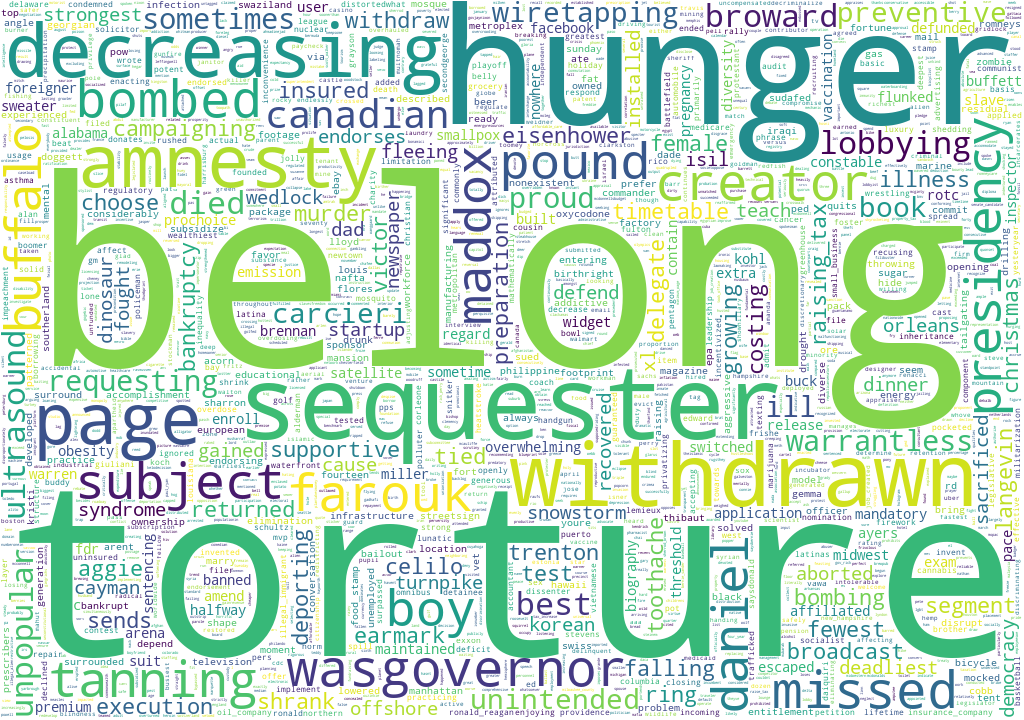

In [20]:
Image("true_news_word_cloud.png", width=600, height=600)

#### Word clouds for fake news

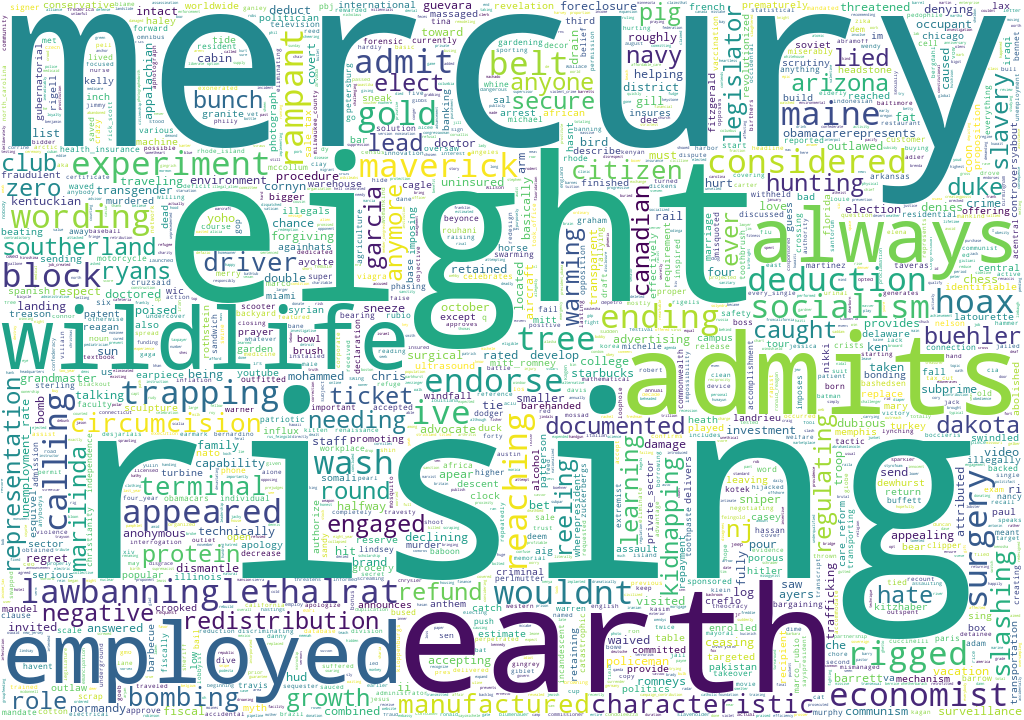

In [21]:
Image("fake_news_word_cloud.png", width=600, height=600)

(Write-up )

### 2.2 Doc2vec embedding and visualizaton through dimensional reduction

Now, we are considering another approach to visualize our dataset. Instead of considering the words that appear frequently in some class labels, we will convert each document to a fixed-length vector in $R^{50}$ through doc2vec model. So this fixed-length vector would contain semantic and syntatic informations about the statements, and then we apply TSNE dimensional reduction algorithms on these high-dimensional vector. We would like to see see whether or not we could find some cluster structures in our dataset.

#### Note on doc2vec model
Similar to word-embedding, Doc2vec is an unsupervised learning algorithm which represents each document as a fixed-length feature vector. It was proposed by Tomas Mikolov and Quoc Le back in 2014. Feel free to check out the original paper [here](https://arxiv.org/pdf/1405.4053.pdf). 
Compared to bag-of-word (BoW) model, doc2 embeds the semantics information of the documents in the vector space. BoW would lose the order of words and therefore ignores the semantics information. In case you don't know what bag-of-words model is, [here](https://machinelearningmastery.com/gentle-introduction-bag-words-model/) is a good introduction to bag-of-words model. In addition, length of BoW model is always equal to the size of the dictionary, which could be memory expensive. Doc2vec model could transfer a variable-length piece of text into an artibrary length (fixed) vector. The length is a hyperparameter fixed during the training process.

First, we train a doc2vec model on the training corpus. 

In [22]:
# Tagging each statement for the doc2vec model
tagged_corpus = [TaggedDocument(text, [i]) for i, text in enumerate(train_corpus)] 
# Create a doc2vec model of vector size 50.
doc2vec_model = Doc2Vec(vector_size=50, min_count=2, epochs=100)
#Build a vocabulary from the training corpus
doc2vec_model.build_vocab(tagged_corpus) 
doc2vec_model.train(tagged_corpus, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

Then we transform each statement, which is a list of words now (text data) into a vector (numerical data).

In [23]:
def doc2vec_transform(corpus):
    # Retreiving the vector representation for each statement
    doc2vecX = []
    for text in corpus:
        vector = list(doc2vec_model.infer_vector(text))
        doc2vecX.append(vector)
    doc2vecX = np.array(doc2vecX)
    return doc2vecX

# Transferring the training, validation and test corpus to doc2vec vector representation
train_X = doc2vec_transform(train_corpus)
valid_X = doc2vec_transform(valid_corpus)
test_X  = doc2vec_transform(test_corpus)

Next, we will combine the vector representation of the text data together with the credit history of the person, which is column index 8 to 11 which basically counts how many fake or true statements does the speaker make in the past. That's because the credit history could be a good indicator of the statement that the speaker is making now.

In [24]:
def get_credit_info(df):
    # Slicing column 8 to 12
    credit = np.array(df.iloc[:,8:13])
    row_sums = credit.sum(axis = 1)
    credit = list(credit)
    # Apply the normalization, converting each index to percentage
    # Here since some of the rows have row_sum equals to zero, we will
    # not use the vectorized implementation (broadcasting).
    for i in range(row_sums.shape[0]):
        if (row_sums[i] != 0):
            credit[i] = credit[i] / row_sums[i]
        if (np.isnan(row_sums[i])):
            credit[i] = np.zeros(credit[i].shape)
    return np.array(credit)

train_credit = get_credit_info(train_df)
valid_credit = get_credit_info(valid_df)
test_credit  = get_credit_info(test_df)

# Stacking up the vector representation of text and credit history together
train_X = np.hstack((train_X, train_credit))
valid_X = np.hstack((valid_X, valid_credit))
test_X  = np.hstack((test_X,  test_credit)) 

Now, let's apply the dimensional reduction algorithms TSNE on this high dimensional space ($R^{55}$). TSNE is the Synonym for  T-distributed Stochastic Neighbor Embedding algorithms, which was orignally Laurens van der Maaten and Geoffrey Hinton in 2008.
Feel free to check out the original paper [here](http://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf). We choose TSNE here since it's a nonlinear dimensional reduction algorithm designed for embedding high-dimensional structures in a low dimensional space for visualization.

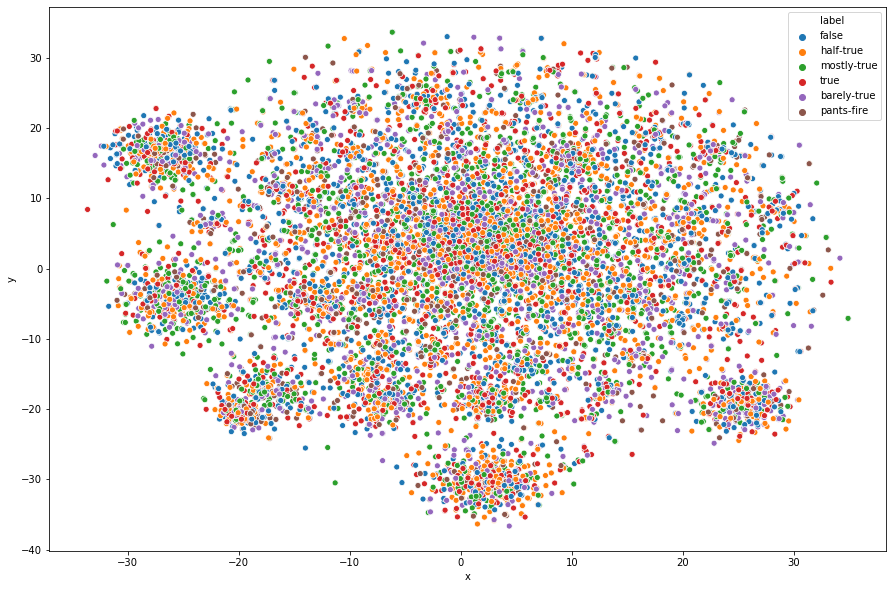

In [25]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X) # Apply Z-standardization on training data
X_embedded = TSNE(n_components=2, perplexity = 50, random_state = 0, verbose = 0).fit_transform(train_X)

# Making the scatter plot now
dims = (15, 10)
df = pd.DataFrame(X_embedded,columns = ["x","y"])
df["label"] = train_df["label"]
fig, ax = plt.subplots(figsize=dims)
ax = sns.scatterplot(x="x", y="y", hue="label",data=df)

From this plot, we see that there is probably some clusters inside in training set, but the structures of each category are not  clear at all in $R^{2}$, unlike the nice cluster structures getting from the famous MNIST dataset. So it could indicate that the the problem of fake news itself is very challenging. As we have discussed before, there are more than just linguistic features that will determine whether a statement is fake news or not. Also in some cases, fake news classification could be confusing. For example, a claim that was considered a fake news ten years ago might be a true news now.

### 2.3 Topic Modelling

Similar to clustering algorithms like k-means, which you might be more familiar with,  topic modeling is a frequently used unsupervised learning algorithms for discovering hidden semantic structures in a text body. Intuitively, given that the document is about a particular topic, we would expect particular set of words to appear in the document more or less frequently. For example,"health","care", "Obama" might appear together in the cluster of statements talking about Obamacare. So the topic modelling algorithms are just trying to find such type of latent semantic structures inside the corpus. In this tutorial, we will use Latent Dirichlet Allocation (LDA) algorithms for topic modelling. Notice that lDA algorithm is a probabilistic model, meaning that for each statement, instead of "hard" clustering, we compute the probability of it being every possible topic. So suppose we want to generate a LDA model with number of topics 10, then each output will be a 10-demsional vector, and its $ith$ component is the probability that the statement belongs to topic $i$. Here is a [gentle introduction to LDA algorithms](http://blog.echen.me/2011/08/22/introduction-to-latent-dirichlet-allocation/) and the [original paper](http://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf). Feel free to check them out.

<img src="topic_modelling.jpg" width="600" height="400"> 
Image retreived from [here](https://medium.com/nanonets/topic-modeling-with-lsa-psla-lda-and-lda2vec-555ff65b0b05)

In [26]:
# Train LDA model.
lda_model = LdaModel(bow_train,id2word=dictionary.id2token, num_topics=10, passes=20, iterations=600,  eval_every=None)
top_topics = lda_model.top_topics(bow_train) #, num_words=20)

# Average topic coherence is the sum of topic coherences of all topics, divided by the number of topics.
avg_topic_coherence = sum([t[1] for t in top_topics]) / 10
print('Average topic coherence: %.4f.' % avg_topic_coherence)

pprint(top_topics[0])

Average topic coherence: -6.3634.
([(0.054144982, 'year'),
  (0.04286214, 'job'),
  (0.024763344, 'million'),
  (0.02179496, 'last'),
  (0.021422427, 'state'),
  (0.01415772, 'since'),
  (0.011978702, 'office'),
  (0.011820109, 'dollar'),
  (0.010553572, 'lost'),
  (0.010408768, 'percent'),
  (0.009499819, 'every'),
  (0.009428326, 'last_year'),
  (0.009034817, 'two'),
  (0.008730996, 'took'),
  (0.0079329265, 'wisconsin'),
  (0.0076214517, 'created'),
  (0.0075498484, 'month'),
  (0.007420365, 'past'),
  (0.00693739, 'spent'),
  (0.006921775, 'per')],
 -3.9441496146630137)


To see the clustering structures of our topic modelling, we now apply TSNE dimensional reduction algorithms one more time. However, this time we are not labelling each statement by whether it's fake or not. Instead, we are labelling each statement by its most possible topic number. 

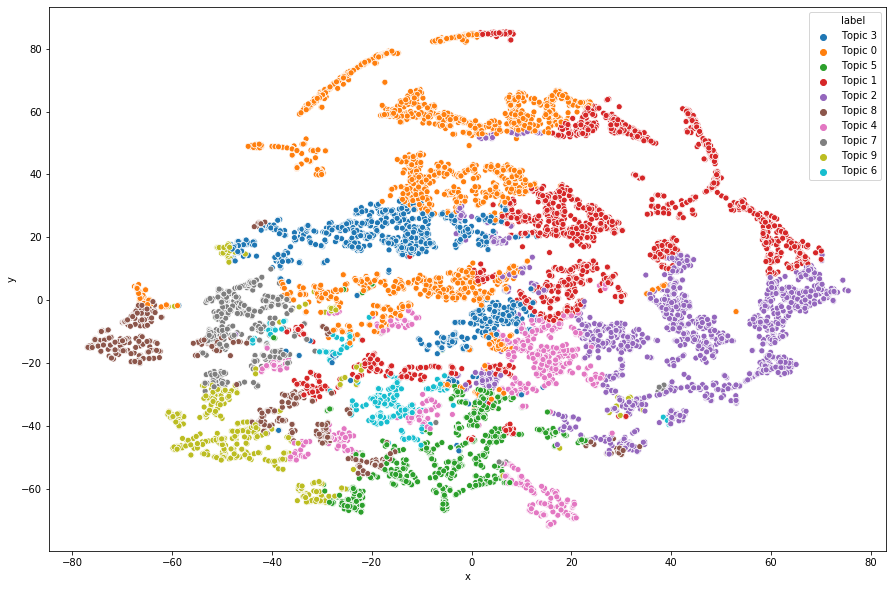

In [27]:
topic_weights = []
for document in bow_train:
    weight = lda_model[document]
    weight = [pair[1] for pair in weight]
    topic_weights.append(weight)
    
# Convert the topic weights of each statement into numpy array
topic_weights = pd.DataFrame(topic_weights).fillna(0).values
# Compute the dominant topic number for each statement
topic_num = np.argmax(topic_weights, axis=1)
topics = list(map(lambda x: "Topic " + str(x), topic_num))

# Apply TSNE Dimension Reduction again
tsne = TSNE(n_components=2, perplexity = 50, random_state = 0, verbose = 0)
topic_embedded = tsne.fit_transform(topic_weights)
dims = (15, 10)
df = pd.DataFrame(topic_embedded,columns = ["x","y"])
df["label"] = topics
fig, ax = plt.subplots(figsize=dims)
ax = sns.scatterplot(x="x", y="y", hue="label",data=df)

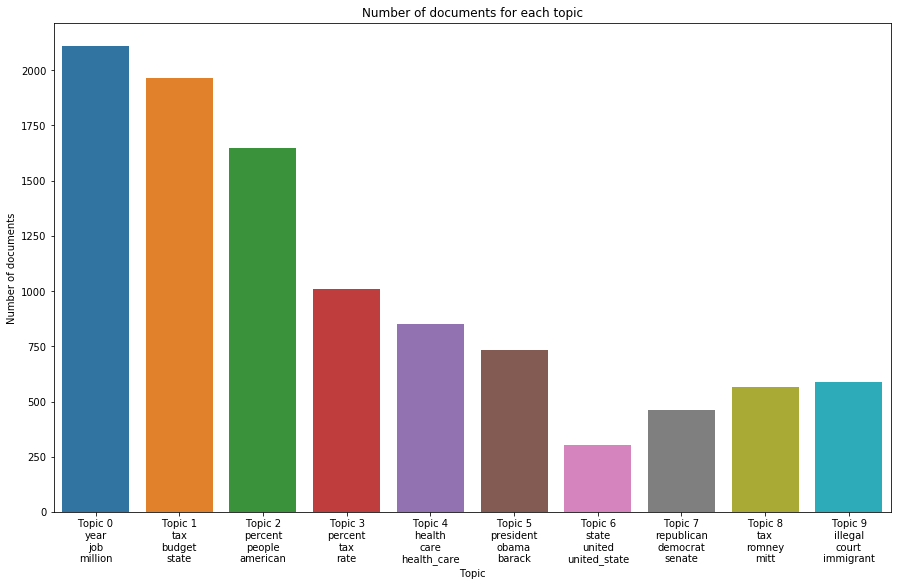

In [28]:
topics = [(i, j) for (i,j) in enumerate(topic_num)]
topic_df = pd.DataFrame(topics, columns=['Document_Id', 'Topic_id'])
count_topics = topic_df.groupby('Topic_id').size()
count_topics = count_topics.to_frame(name='count').reset_index()

fig_size = (15, 9)
fig, ax = plt.subplots(figsize=fig_size)
ax = sns.barplot(x = 'Topic_id', y = 'count', data = count_topics)
ax.set_xticks(range(10))
tick_formatter = FuncFormatter(lambda x, pos: 'Topic ' + str(x)+ '\n' + top_topics[x][0][0][1]
                              +'\n'+top_topics[x][0][1][1]+'\n'+top_topics[x][0][2][1])
ax.xaxis.set_major_formatter(tick_formatter)
_  = ax.set(xlabel="Topic", ylabel= "Number of documents")
_  = ax.set_title("Number of documents for each topic")
plt.show()

# Fake news detection with supervised learning algorithms

Now we have a rather good understanding of the dataset and the general structure of fake news. Let's apply various supervised learning algorithms to our dataset. But before we step into these amazing models, let's first do some further transformations on the dataset to prepare the data for our supervised learning algorithms.

### 3.1 Data preparing

In order for the deep learning algorithms that we will apply later, We have to transform the ordinal data of the labels into numerical values, and then we apply a one-hot encoding to transform each of the label into a 6-dimensional vector. For example, if the label is pants-fire, then one-hot encoded vector would be $[1,0,0,0,0,0]^{T}$

In [29]:
def label_transform(df):
    Y = df["label"]
    # Apply a map to the set of labels in order to transfer the ordinal label data into numerical value
    mapping = {"pants-fire":0,"false":1,"barely-true":2,"half-true":3 ,"mostly-true":4,"true":5}
    Y = np.array(Y.map(mapping))
    # One-hot encoding
    Y = np_utils.to_categorical(Y)
    return Y

train_Y = label_transform(train_df)
valid_Y = label_transform(valid_df)
test_Y  = label_transform(test_df)

### 3.2 Basedline model: K Nearest Neighbors

We implement K nearest neighbors (KNN) as our baseline model. The idea behind K nearest neighbors model is very simple. For every point to predict, it computes the K nearest point from the training set through some given metrics, e.g. Euclidean distance or Manhattan distance. Then it average the label over these K neighbors and make the final prediction. <br>

The disadvantage of the K-nearest neighbors is that it's vulnerable to the famous [curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality). Since each of our input is a 55-dimensional vector, the distance metrics might lose sense in this high-dimensional space, which is the biggest problem of the K-nearest neighbour algorithm.

In [30]:
# Set up the search space of number of n_neibours
n_neighbors = [int(x) for x in np.linspace(start = 3, stop = 15, num = 13)]
# Search for weights, whether the points are sampled uniformly or by distance
# such as neighbors closer to the point to predict would have higher probability
# to be selected
weights = ["uniform", "distance"]
# Power parameter for the Minkowski metric
p = [1,2,3,4]
grid = {'n_neighbors': n_neighbors, 'weights': weights, 'p':p}

# Set up the base estimator and do the random grid search
knn = KNeighborsClassifier()
knn = RandomizedSearchCV(estimator = knn, param_distributions = grid, cv = 5,\
                           verbose = 1, random_state = 0, n_jobs = -1)
knn.fit(train_X, train_Y)
print(knn.best_params_)
print("Best 10-fold cross validation accuracy: {}".format(knn.best_score_))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  9.8min


{'weights': 'uniform', 'p': 2, 'n_neighbors': 3}
Best 10-fold cross validation accuracy: 0.26123485736615865


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 11.8min finished


In [31]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(train_X, train_df["label"])
print("Training set accuracy:{}".format(knn.score(train_X, train_df["label"])))
print("Cross-validation set accuracy:{}".format(knn.score(valid_X, valid_df["label"])))
print("Test set accuracy:{}".format(knn.score(test_X, test_df["label"])))

Training set accuracy:0.6044353262993357
Cross-validation set accuracy:0.21495327102803738
Test set accuracy:0.17679558011049723


### 3.3 Random Forest

Next, let's try the random forest algorithms on our training set. Random forest algorithm is an esmeble learning algorithms that people use fairly often in data science competition like Kaggle competition. The huge advantage of random forest algorithms is the robustness to the noise in the data because of its randomness. We are not going explain in details how random forest work here. But if you want to learn more about how random forest words, feel free to check out this tutorial [here](https://towardsdatascience.com/an-implementation-and-explanation-of-the-random-forest-in-python-77bf308a9b76). In case you want to know more about the statistical theory behind random forest, check out chapter 8 of the book An Introduction to Statistical Learning with Applications in R. Here is a [link](http://faculty.marshall.usc.edu/gareth-james/ISL/) to the website of this book.

In [32]:
# Set up the search space of number of n_estimators
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 299, num = 10)]
# Set up the search space of max_depth
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
# Search the criterion for measuring the quality of a split
criterion = ["gini","entropy"]
grid = {'n_estimators': n_estimators, 'max_depth': max_depth, "criterion":criterion}

# Set up the base estimator and do the random grid search
randf = RandomForestClassifier(random_state = 0)
randf = RandomizedSearchCV(estimator = randf, param_distributions = grid, cv = 5,\
                           verbose = 1, random_state = 0, n_jobs = -1)
randf.fit(train_X, train_Y)

print("Best parameters: ", randf.best_params_)
print("Best 10-fold cross validation accuracy: {}".format(randf.best_score_))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 12.9min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 13.7min finished


{'n_estimators': 266, 'max_depth': 20, 'criterion': 'gini'}
Best 10-fold cross validation accuracy: 0.20711215318483783


In [33]:
rf = RandomForestClassifier(n_estimators = 74, max_depth = 20, random_state = 0)
rf.fit(train_X, train_df["label"])
print("Training set accuracy:{}".format(rf.score(train_X, train_df["label"])))
print("Cross-validation set accuracy:{}".format(rf.score(valid_X, valid_df["label"])))
print("Test set accuracy:{}".format(rf.score(test_X, test_df["label"])))

Training set accuracy:0.9998046111762408
Cross-validation set accuracy:0.32320872274143303
Test set accuracy:0.30386740331491713


### 3.4 Support Vector Machine (with & without RBF kernel)

First, let's fit the linear support vector machine(SVM) on the training data based on the default hyperparameter settings. In case you are not familiar with how support vector machine, [here](https://medium.com/machine-learning-101/chapter-2-svm-support-vector-machine-theory-f0812effc72) is a gentle tutorial on SVM.

In [34]:
clf = svm.LinearSVC(random_state = 0)
clf.fit(train_X, train_df["label"])

print("Training set acuracy:{}".format(clf.score(train_X, train_df["label"])))
print("Validation set acuracy:{}".format(clf.score(valid_X, valid_df["label"])))
print("Testing set accuracy:{}".format(clf.score(test_X, test_df["label"])))

Training set acuracy:0.4817311449785072
Validation set acuracy:0.39485981308411217
Testing set accuracy:0.38437253354380424


#### Support vector machine with RBF kernel mapping

In [35]:
# Transform the training, validation and testing data
feature_map_nystroem = Nystroem(gamma=.2, random_state=0, n_components=400)
train_data_transformed = feature_map_nystroem.fit_transform(train_X)
valid_data_transformed = feature_map_nystroem.fit_transform(valid_X)
test_data_transformed = feature_map_nystroem.fit_transform(test_X)

clf.fit(train_data_transformed, train_df["label"])

# Printing out the model accuracy
print("Training set acuracy:{}".format(clf.score(train_data_transformed, train_df["label"])))
print("Validation set acuracy:{}".format(clf.score(valid_data_transformed, valid_df["label"])))
print("Testing set accuracy:{}".format(clf.score(test_data_transformed, test_df["label"])))

Training set acuracy:0.2629933567799922
Validation set acuracy:0.1853582554517134
Testing set accuracy:0.18705603788476716


As we see, linear support vector machine without RBF kernel works much better than the model with RBF kernel in our example. So again, let's use random grid search to fine-tune the hyperparameters of linear support vector machines.

In [36]:
# Search the penalty parameter C
C = [x for x in np.linspace(0.5, 5.0, 10)]
# Search for loss function
loss = ["hinge","squared_hinge"]
# Search whether to encode class weights
class_weight = [None, "balanced"]

grid = {"C": C, "loss": loss, "class_weight": class_weight}

# Set up the base estimator and do the random grid search
clf = svm.LinearSVC(random_state = 0)
clf = RandomizedSearchCV(estimator = clf, param_distributions = grid, cv = 10,\
                           verbose = 1, random_state = 0, n_jobs = -1)
clf.fit(train_X, train_df["label"])
print("Best parameters: ", clf.best_params_)
print("Best 10-fold cross validation accuracy: {}".format(clf.best_score_))

Fitting 10 folds for each of 10 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 10.0min finished


{'loss': 'squared_hinge', 'class_weight': 'balanced', 'C': 1.5}
Best 10-fold cross validation accuracy: 0.46561156701836653


In [37]:
clf = svm.LinearSVC(C = 4.0, random_state = 0)
clf.fit(train_X, train_df["label"])

# Printing out the model accuracy
print("Training set acuracy:{}".format(clf.score(train_X, train_df["label"])))
print("Validation set acuracy:{}".format(clf.score(valid_X, valid_df["label"])))
print("Testing set accuracy:{}".format(clf.score(test_X, test_df["label"])))

Training set acuracy:0.4720593982024228
Validation set acuracy:0.38006230529595014
Testing set accuracy:0.40173638516179955


### 3.5 Deep learning: feed-forward neural network

In our model, we will use three layers of feed-forward network, together with two dropout layers in order to reduce the overfit. To learn more about the dropout, check out the original paper [here](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). <br>
Notice that the last layer of our neural net is the softmax layer which computes the probability of each class by $$P(y = j | X) = \frac {e^{X^{T}W_{j}}}{\sum_{k=1}^{N}e^{X^{T}W_{k}}}$$ (Note: Softmax could be viewed as a multiclass generalization of logistic regression. In logistic regression, we model $Y|X$ as Bernoulli distribution $B(\phi)$, where in softmax regression, we model $Y|X$ as categorical distribution $\vec{\boldsymbol{\phi}}$, where $P(Y=j|X)=\vec{\boldsymbol{\phi}_{j}}$
Apart from dropout, based on the model selection experiments that we do beforehand, where we fit the model based on different sets of hyperparameters and evaluate the performance on the cross-validation set, we also choose to apply both the L2 regularizer with penalty 0.01. Furthermore, we find dropout layers with probability 0.5 work the best in our cross-validation set.

<img src="TensorBoard.PNG" width="500" height="500"> 
Here is a diagram of our neural network model generated from TensorBoard, a visualization tool implemented by TensorFlow.

In [38]:
# Set-up the model
model = Sequential()

# Input layer, here we apply l2 regularization with penalty 0.01
model.add(Dense(32, input_dim = 55, activation = 'relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.2, seed=0))
model.add(Dense(16, activation = 'relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.2, seed=1))
model.add(Dense(6, activation='softmax'))

# Compile the model, we will use adam optimizer in our model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 32)                1792      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dropout_2 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 6)                 102       
Total params: 2,422
Trainable params: 2,422
Non-trainable params: 0
_________________________________________________________________
None


In [39]:
history = model.fit(train_X, train_Y, batch_size = 128, epochs = 30, validation_data = (valid_X, valid_Y))

Train on 10236 samples, validate on 1284 samples
Epoch 1/30
10236/10236 [==============================] - 0s 48us/step - loss: 2.4327 - accuracy: 0.2111 - val_loss: 2.2342 - val_accuracy: 0.2165
Epoch 2/30
10236/10236 [==============================] - 0s 13us/step - loss: 2.1074 - accuracy: 0.2802 - val_loss: 2.1010 - val_accuracy: 0.2445
Epoch 3/30
10236/10236 [==============================] - 0s 13us/step - loss: 1.9314 - accuracy: 0.3358 - val_loss: 2.0019 - val_accuracy: 0.2726
Epoch 4/30
10236/10236 [==============================] - 0s 17us/step - loss: 1.7964 - accuracy: 0.3739 - val_loss: 1.9175 - val_accuracy: 0.3131
Epoch 5/30
10236/10236 [==============================] - 0s 16us/step - loss: 1.6961 - accuracy: 0.4010 - val_loss: 1.8535 - val_accuracy: 0.3279
Epoch 6/30
10236/10236 [==============================] - 0s 16us/step - loss: 1.6293 - accuracy: 0.4179 - val_loss: 1.8007 - val_accuracy: 0.3645
Epoch 7/30
10236/10236 [==============================] - 0s 18us/ste

Then we plot the accuracy and loss of our model vs. epoch.

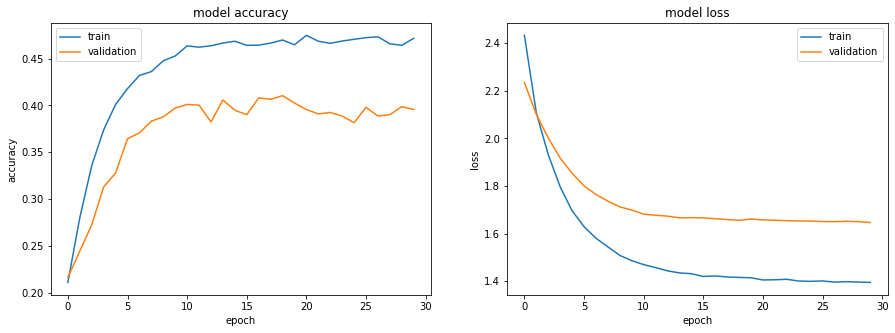

In [40]:
figure, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize = (15,5))

# Plot the model accuracy in the training history
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('model accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend(['train', 'validation'], loc='upper left')

# Plot the model accuracy in the training history
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('model loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend(['train', 'validation'], loc='upper right')

As we see in the graph, after about epoch 5, the accuracy on the test set begin to oscillate, and after about 10 epochs, the loss on the training and the cross-validation set barely decrease any more. So this is roughly where the neural network begins to overfit the data. <br>

Suprisingly, our neural net model with Doc2vec embeddings work much better than the Convolutional Neural Network (CNN) with word embedding model implemented by the original paper, which only achieves 27.7% accuracy on the validation set and 27.4% accuracy on the test set at best. Our speculation here is that overfitting of CNN might be an issue. More importantly, we think that Doc2vec model probably works much better than word embedding models in this dataset since for other machine learning algorithms like Linear SVM which we implemented earlier, it also achieve much higher accuracy on the cross-validation set than the original paper. We speculate that the huge variation of number of words contained different training samples might be a reason that word emedding doesn't work well. 

### 3.6 Comparing perfomance of different machine learning models on test set & hypothesis testing

Let's first compute the perfomance of neural net on test set. 

In [41]:
print("Accuracy of the model on the test set {}".format(model.test_on_batch(test_X, test_Y)[1]))

Accuracy of the model on the test set 0.3951391577720642


Below is the table of the performance of machine learning algorithms on the training, cross-validation set and test set.

<table>
  <tr>
    <th>Models</th>
    <th>Validation Set</th>
    <th>Test Set</th>
  </tr>
  <tr>
    <td>K nearest neighbors</td>
    <td>20.3</td>
    <td>20.8</td>
  </tr>
  <tr>
    <td>Random Forest</td>
    <td>31.2</td>
    <td>28.7</td>
  </tr>
  <tr>
    <td>Support Vector Machine</td>
    <td>39.4</td>
    <td>36.3</td>
  </tr>
  <tr>
    <td>Neural network</td>
    <td><span style="font-weight:bold">39.6</span></td>
    <td><span style="font-weight:bold">38.5</span></td>
  </tr>
</table>

### Paired t-test of neural net vs. k-nearest neighbors, random forest and support vector machine

Now, let's consider a different way of model comparison. Instead of measuring their performance on the test set, we will instead do paired t-test. For each pair of algorithms, $A$ and $B$, we have null hypothesis $H_{0}$ be that the accuracy between model $A$ and $B$ are the same. Then we compute the T-statistics and P-values based on their performance (accuracy) on each fold of the 10-fold cross validation. If P-values $p >= 0.05$, we will retain the hypothesis that $A$ and $B$ have the same accuracy. If $p < 0.05$ and t statistics $t > 0$, then we think that model $A$ has better performance than $B$. If $p < 0.05$ and t statistics $t > 0$, then we think that model $B$ has better performance than $A$. In case you haven't seen hypothesis testing before, [here](https://machinelearningmastery.com/statistical-hypothesis-tests/) is a great introduction

In [42]:
# First, let's compute the accuracy of each model in each fold of the 10-fold cross validation
# These are lists of accuracy for different models on 10-fold cross validation
knn_accuracy, rf_accuracy, svm_accuracy, net_accuracy = [], [], [], []

i = 0
kf = KFold(n_splits=10, shuffle=True, random_state=0)
for train_index, test_index in kf.split(train_X):
    # Getting the training and testing set from K-fold cross validation
    # Here net_train_Y is the one-hot encoding vector of label Y specifically for neural network
    # y_train is just the raw labels that would work for other machine learning algorithms
    x_train, y_train, net_train_Y = train_X[train_index], train_df["label"].iloc[train_index], train_Y[train_index]
    x_test,  y_test,  net_test_Y  = train_X[test_index],  train_df["label"].iloc[test_index],  train_Y[test_index]
    
    # Support Vector Machine
    clf = svm.LinearSVC(C = 4.0, random_state = 0)
    clf.fit(x_train, y_train)
    svm_accuracy.append(clf.score(x_test, y_test))
    # K Nearest Neighbors
    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(x_train, y_train)
    knn_accuracy.append(knn.score(x_test, y_test))
    # Random Forest
    rf = RandomForestClassifier(n_estimators = 74, max_depth = 20, random_state = 0)
    rf.fit(x_train, y_train)
    rf_accuracy.append(rf.score(x_test, y_test))
    
    #Neural Fetwork (using the model defined earlier)
    model.fit(x_train, net_train_Y, batch_size = 128, verbose = 0, epochs = 25)
    net_accuracy.append(model.test_on_batch(x_test, net_test_Y)[1])
    
    i+=1
    print("Finished {} fold".format(i))

Finished 1 fold
Finished 2 fold
Finished 3 fold
Finished 4 fold
Finished 5 fold
Finished 6 fold
Finished 7 fold
Finished 8 fold
Finished 9 fold
Finished 10 fold


In [43]:
# K nearest neighbors vs. Neural network
t, p_value = stats.ttest_rel(knn_accuracy, net_accuracy)
print("T statistics: {} p value of K nearest neighbors vs. Neural network: {}".format(t, p_value))
# Random Forest vs. Neural network
t, p_value = stats.ttest_rel(rf_accuracy, net_accuracy)
print("T statistics: {} p value of Random Forest vs. Neural network: {}".format(t, p_value))
# Support Vector Macchine vs. Neural network
t, p_value = stats.ttest_rel(svm_accuracy, net_accuracy)
print("T statistics: {} p value of Support_vector Machine vs. Neural network: {}".format(t, p_value))

# Random Forest vs. support vector machine
t, p_value = stats.ttest_rel(rf_accuracy, svm_accuracy)
print("T statistics: {} p value of Random Forest vs. Support Vector Machine: {}".format(t, p_value))

# K nearest neighbors vs. Random Forest
t, p_value = stats.ttest_rel(knn_accuracy, rf_accuracy)
print("T statistics: {} p value of K nearest neighbors vs. Random Forest: {}".format(t, p_value))

T statistics: -45.386128960804506 p value of K nearest neighbors vs. Neural network: 6.120920524499045e-12
T statistics: -9.118149867782245 p value of Random Forest vs. Neural network: 7.673048474631552e-06
T statistics: -5.930751487414941 p value of Support_vector Machine vs. Neural network: 0.00022051756344509317
T statistics: -4.16261762682811 p value of Random Forest vs. Support Vector Machine: 0.00243820961228481
T statistics: -22.258589883449307 p value of K nearest neighbors vs. Random Forest: 3.526985767874133e-09


So from the result, while compared other models with neural network, we always get small p-values and negative T statistics. So we always reject the null hypothesis $H_{0}$ and accept that neural network achieves higher accuracy on our dataset.  

For comparison between different non-deep-learning models, we reject the null hypothesis betweem Random Forest and Support Vector Machine, accpeting that Support Vector Machine achieves a higher accuracy on our dataset than Random Forest. For k nearest neighbors vs. random forest, we still reject the null hypothesis and accept that random forest achieves higher accuracy on our dataset than k nearest neighbors 

# Conclusion